In [1]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import PiecewiseGQ2D_weights_points, SquareMesh2D_points
from utils import s2_uniform_grid_init
from utils import output_convergence_order_l2
from utils import plot_err_convergence

In [2]:
class PouShallowReLUkNetwork:
    def __init__(
        self, ws, bs, pts, k=1, l=1, sigma=0.01, m1=1, m2=1):
        
        self.n = ws.shape[0]
        self.d = ws.shape[1]
        self.k = k
        self.l = l
        self.sigma = sigma
        self.m1 = m1 
        self.m2 = m2
        self.pts = pts
        cntrs, rng = self.pou_init()
        self.cntrs, self.rng = cntrs, rng

        self.J = self.cntrs.shape[0]
        self.W = ws.unsqueeze(0).repeat(self.J, 1, 1)   # [J, n, d]
        self.b = bs.unsqueeze(0).repeat(self.J, 1)      # [J, n]
    
    def map_unit(self, x):
        '''
        Inputs:
            x : (N, d)
            cntrs: (J, d)
            rng : float
        Returns:
            x_ : (N, J, d)
        '''
        x_ = (x.unsqueeze(0) - self.cntrs.unsqueeze(1) + self.rng)/(2 * self.rng)
        return x_
    
    def pou_init(self):
        rng = 1 / 2**(self.l)
        cntr_1d = torch.linspace(0, 1, 2**(self.l-1)+1).reshape(-1, 1)
        grid = list(itertools.product(cntr_1d, repeat=2)) # 2 for 2D input
        cntrs = torch.tensor(grid)
        return cntrs, rng

    def pou_extract(self, x):
        '''
        Inputs:
            x : (N, D) tensor
            cntrs : (J, D) tensor 
            rng : scalar (float or tensor)
            sigma : scalar (float or tensor)
        Returns:
            (J, N) tensor
        '''
        def phi(z):
            return 1 / (1 + torch.exp(-z))

        # Expand dimensions for broadcasting: (N,1,D) - (1,M,D) → (N,M,D)
        a = self.cntrs.unsqueeze(1) - self.rng
        b = self.cntrs.unsqueeze(1) + self.rng
        x_exp = x.unsqueeze(0)

        # Apply PoU formula over each dimension
        vals = phi((x_exp - a) / self.sigma) * phi((b - x_exp) / self.sigma)

        # Product over D → (N,M)
        return vals.prod(dim=2, keepdim=False)

    def feat_extract(self, x):
        pou_feat = self.pou_extract(x) # [J, N]
        x_ = self.map_unit(x)
        local_feats = []
        for j in range(self.J):
            feat = F.relu(x_[j] @ self.W[j].t() + self.b[j]) ** self.k
            local_feat = feat * pou_feat[j].unsqueeze(-1)
            local_feats.append(local_feat)
        return torch.hstack(local_feats)

    def target(self, x):
        z = torch.sin(self.m1 * pi*x[:,0:1])*torch.sin(self.m2 * pi*x[:,1:2])
        return z 

    def assemble(self):
        A = self.feat_extract(self.pts)
        b = self.target(self.pts)
        return A, b

    def solve(self):
        A, b = self.assemble()

        c = 100.0 
        for i in range(len(A)):
            max_a = abs(A[i,:]).max()
            max_b = A[i,:].max()
            if max_a != max_b: 
                ratio = -c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
            else: 
                ratio = c/max_a
                A[i,:] = A[i,:]*ratio
                b[i] = b[i]*ratio
        alpha = scipy.linalg.lstsq(A.numpy(),b.numpy())[0]
        self.alpha = torch.tensor(alpha)
        
    def forward(self, x):
        return self.feat_extract(x) @ self.alpha
    
    def eval(self, x):
        y_ref = self.target(x)
        y_pred = self.forward(x)
        rel_errl2 = (y_pred - y_ref).norm() / y_ref.norm()
        return rel_errl2.item()

In [3]:
x_train = SquareMesh2D_points(0,1,100)
x_test = SquareMesh2D_points(0,1,150)

k = 1
m1 = 4
m2 = 4
neuron_num_arr= np.array([2**i for i in range(2,11)]) 
neuron_arr = []
rel_errl2_arr = []
for i, n in enumerate(neuron_num_arr):
    ws, bs = s2_uniform_grid_init(n, k=k)
    model = PouShallowReLUkNetwork(
        ws, bs, x_train, k=k, m1=m1, m2=m2)
    model.solve()
    rel_errl2 = model.eval(x_test)
    neuron_arr.append(model.n)
    rel_errl2_arr.append(rel_errl2)
    print('num neuron : {:} - rel l2 : {:.4e}'.format(model.n * model.J, rel_errl2))
title = "L2 fitting. ReLU$^{}$. $\sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m1, m2)

num neuron : 12 - rel l2 : 1.0004e+00
num neuron : 24 - rel l2 : 9.5246e-01
num neuron : 36 - rel l2 : 8.8787e-01
num neuron : 68 - rel l2 : 7.7793e-01
num neuron : 124 - rel l2 : 4.8167e-01
num neuron : 228 - rel l2 : 3.3003e-01
num neuron : 452 - rel l2 : 1.4238e-01
num neuron : 908 - rel l2 : 6.1244e-02
num neuron : 1780 - rel l2 : 2.6923e-02


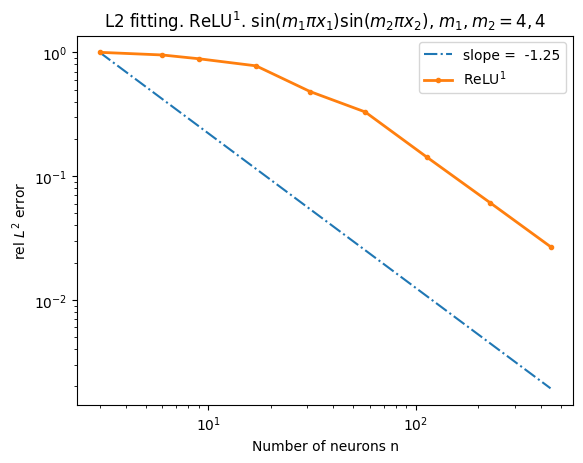

$n$ & 	 $\|u-u_n \|_{L^2}$ & 	 order  \\ \hline \hline 
3 		 & 1.000e+00 &		 *  \\ \hline  

6 		 &  9.525e-01 &  		 0.07  \\ \hline  

9 		 &  8.879e-01 &  		 0.17  \\ \hline  

17 		 &  7.779e-01 &  		 0.21  \\ \hline  

31 		 &  4.817e-01 &  		 0.80  \\ \hline  

57 		 &  3.300e-01 &  		 0.62  \\ \hline  

113 		 &  1.424e-01 &  		 1.23  \\ \hline  

227 		 &  6.124e-02 &  		 1.21  \\ \hline  

445 		 &  2.692e-02 &  		 1.22  \\ \hline  



In [4]:
plot_err_convergence(1,2,torch.tensor(neuron_arr), rel_errl2_arr,title)
output_convergence_order_l2(torch.tensor(neuron_arr), rel_errl2_arr)

In [3]:

def plot_err_convergence_levels(relu_k, d, neuron_dict, err_dict, levels, title, outpath):
    """
    Plot L2 error convergence for multiple levels l, saving to file only.

    Parameters:
        relu_k : int
            Degree of ReLU (k)
        d : int
            Input dimension
        neuron_dict : dict of arrays
            Each element: actual_neuron_arr for one level l
        err_dict : dict of arrays
            Each element: mean_err_l2_arr for one level l
        levels : list
            List of level parameters corresponding to neuron_dict / err_dict
        title : str
            Plot title
        outpath : str
            Path to save the figure
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    L2J = {1: 4, 2: 9, 3: 25}

    for l in levels:
        neurons = neuron_dict[l]
        err = err_dict[l]
        if l == 0:
            optimal_rate = 1/2 + (2 * relu_k + 1) / (2 * d)
                        
            if ("Delta" in title) & ("4, 4" in title):
                scale = 10**4
            elif "Delta" in title:
                scale = 10**2
            else:
                scale = 1
            ref = err[0] * neurons[0]**optimal_rate * neurons**(-optimal_rate) * scale 
            ax.plot(neurons, ref, '--', label=f'slope = -{optimal_rate:.2f}')
            ax.plot(neurons, err, '.-', label=f'ReLU$^{relu_k}$', linewidth=2)
        else:
            ax.plot(neurons, err, '.-', label=f'J = {L2J[l]}, ReLU$^{relu_k}$', linewidth=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of neurons n")
    ax.set_ylabel("rel $L^2$ error")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # fig.savefig(outpath, dpi=300, bbox_inches="tight")
    # plt.close(fig)
    plt.show()


start exp (l2fit) : k 4 - m 16
num neuron : 3 - rel l2 : 1.0010e+00
num neuron : 6 - rel l2 : 9.9967e-01
num neuron : 11 - rel l2 : 9.9992e-01
num neuron : 23 - rel l2 : 9.9927e-01
num neuron : 43 - rel l2 : 9.9845e-01
num neuron : 69 - rel l2 : 9.9786e-01
num neuron : 125 - rel l2 : 9.9613e-01
num neuron : 239 - rel l2 : 9.7176e-01
num neuron : 457 - rel l2 : 7.8104e-01
num neuron : 909 - rel l2 : 3.8637e-01
num neuron : 1809 - rel l2 : 6.4281e-02
local 4 num neuron : 12 - rel l2 : 1.0008e+00
local 4 num neuron : 24 - rel l2 : 1.0045e+00
local 4 num neuron : 44 - rel l2 : 1.0006e+00
local 4 num neuron : 92 - rel l2 : 1.0016e+00
local 4 num neuron : 172 - rel l2 : 9.9380e-01
local 4 num neuron : 276 - rel l2 : 9.8460e-01
local 4 num neuron : 500 - rel l2 : 9.4955e-01
local 4 num neuron : 956 - rel l2 : 8.0763e-01
local 4 num neuron : 1828 - rel l2 : 3.3862e-01
local 9 num neuron : 27 - rel l2 : 1.0114e+00
local 9 num neuron : 54 - rel l2 : 1.0088e+00
local 9 num neuron : 99 - rel l2 : 

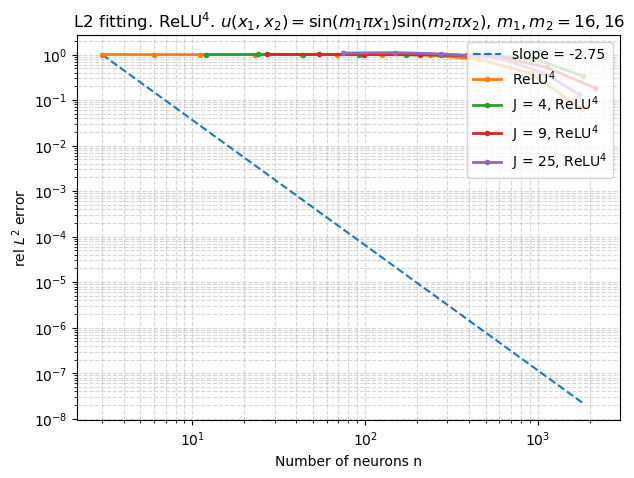

In [9]:
import torch 
import torch.nn as nn
import torch.nn.functional as F
import os 
import numpy as np 
import itertools
import scipy 
import math
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
pi = torch.tensor(np.pi,dtype=torch.float64)

from utils import SquareMesh2D_points
from utils import s2_uniform_grid_init
# from utils import plot_err_convergence_levels
from model import ShallowReLUkFitter
from model import PouShallowReLUkFitter


def run_exp(k, m, l, nmin=6, nmax=13, neuron_max=2500):
    x_train = SquareMesh2D_points(0,1,100)
    x_test = SquareMesh2D_points(0,1,150)

    if l == 0:
        # Global fitter
        neuron_num_arr= np.array([2**i for i in range(nmin, nmax)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = ShallowReLUkFitter(
                ws, bs, x_train, k=k, m1=m, m2=m)
            if fitter.n > neuron_max:
                break
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n)
            rel_errl2_arr.append(rel_errl2)
            print('num neuron : {:} - rel l2 : {:.4e}'.format(fitter.n, rel_errl2))
    else:
        neuron_num_arr= np.array([2**i for i in range(2,11)]) 
        neuron_arr = []
        rel_errl2_arr = []
        for i, n in enumerate(neuron_num_arr):
            ws, bs = s2_uniform_grid_init(n, k=k)
            fitter = PouShallowReLUkFitter(
                ws, bs, x_train, l=l, k=k, m1=m, m2=m)
            if fitter.J * fitter.n > neuron_max:
                break 
            fitter.solve()
            rel_errl2 = fitter.eval(x_test)
            neuron_arr.append(fitter.n*fitter.J)
            rel_errl2_arr.append(rel_errl2)
            print('local {:} num neuron : {:} - rel l2 : {:.4e}'.format(fitter.J, fitter.n*fitter.J, rel_errl2))

    return np.array(neuron_arr), np.array(rel_errl2_arr)

if __name__ == '__main__':

    k_list = [4]
    m_list = [16]
    l_list = [0, 1, 2, 3]
    neurons_dict = {}
    errs_dict = {}
    for k in k_list:
        for m in m_list:
            print(f'start exp (l2fit) : k {k} - m {m}')
            neuron_dict_outpath = f'./logs/l2fit_neurons_k{k}_m{m}.npy'
            err_dict_outpath = f'./logs/l2fit_errs_k{k}_m{m}.npy'

            if os.path.exists(neuron_dict_outpath) & os.path.exists(err_dict_outpath):
                neurons_dict = np.load(neuron_dict_outpath, allow_pickle=True).item()
                errs_dict = np.load(err_dict_outpath, allow_pickle=True).item()
            else:
                for l in l_list:
                    neurons, errs = run_exp(k, m, l, 2, 13)
                    neurons_dict[l] = neurons
                    errs_dict[l] = errs

                np.save(neuron_dict_outpath, neurons_dict)
                np.save(err_dict_outpath, errs_dict)
            title = "L2 fitting. ReLU$^{}$. $u(x_1, x_2) = \sin(m_1\pi x_1) \sin(m_2\pi x_2)$, $m_1,m_2 = {}, {}$".format(k, m, m)
            outpath = f'./figures/l2fit_k{k}_m{m}.jpg'
            print(f'save figure {outpath}')
            plot_err_convergence_levels(relu_k=k, d=2,
                            neuron_dict=neurons_dict,
                            err_dict=errs_dict,
                            levels=l_list,
                            title=title,
                            outpath=outpath)


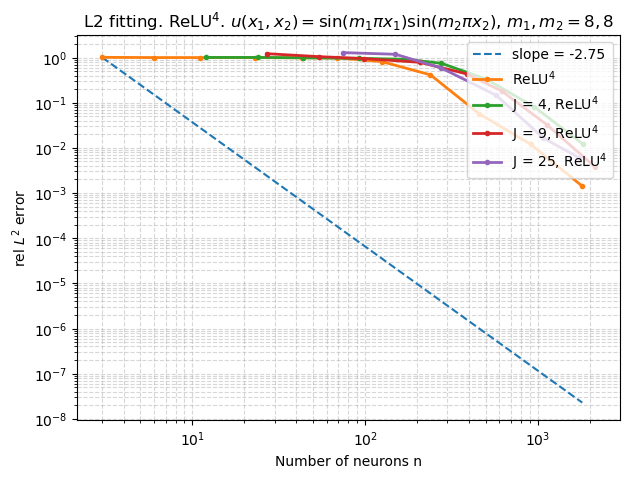

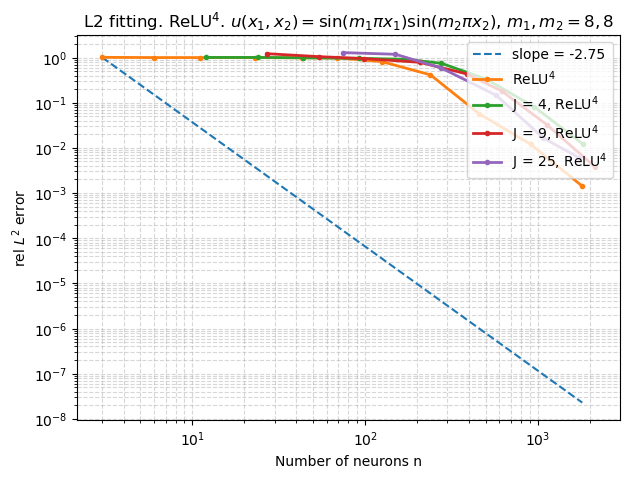

In [8]:
%matplotlib inline 
def plot_err_convergence_levels(relu_k, d, neuron_dict, err_dict, levels, title, outpath):
    """
    Plot L2 error convergence for multiple levels l, saving to file only.

    Parameters:
        relu_k : int
            Degree of ReLU (k)
        d : int
            Input dimension
        neuron_dict : dict of arrays
            Each element: actual_neuron_arr for one level l
        err_dict : dict of arrays
            Each element: mean_err_l2_arr for one level l
        levels : list
            List of level parameters corresponding to neuron_dict / err_dict
        title : str
            Plot title
        outpath : str
            Path to save the figure
    """
    fig, ax = plt.subplots(figsize=(7, 5))
    L2J = {1: 4, 2: 9, 3: 25}

    for l in levels:
        neurons = neuron_dict[l]
        err = err_dict[l]
        if l == 0:
            optimal_rate = 1/2 + (2 * relu_k + 1) / (2 * d)
                        
            if ("Delta" in title) & ("4, 4" in title):
                scale = 10**4
            elif "Delta" in title:
                scale = 10**2
            else:
                scale = 1
            ref = err[0] * neurons[0]**optimal_rate * neurons**(-optimal_rate) * scale 
            ax.plot(neurons, ref, '--', label=f'slope = -{optimal_rate:.2f}')
            ax.plot(neurons, err, '.-', label=f'ReLU$^{relu_k}$', linewidth=2)
        else:
            ax.plot(neurons, err, '.-', label=f'J = {L2J[l]}, ReLU$^{relu_k}$', linewidth=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Number of neurons n")
    ax.set_ylabel("rel $L^2$ error")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.grid(True, which="both", ls="--", alpha=0.5)

    # fig.savefig(outpath, dpi=300, bbox_inches="tight")
    # plt.close(fig)
    plt.show()

plot_err_convergence_levels(relu_k=k, d=2,
                neuron_dict=neurons_dict,
                err_dict=errs_dict,
                levels=l_list,
                title=title,
                outpath=outpath)

